# PTI-Clima Notebooks

> Este cuaderno o notebook ilustra el uso de los conjuntos de datos de la PTI-Clima que se incluyen en el [almacén de datos](https://pti.climate.ifca.es/data). Este trabajo está licenciado bajo una [Licencia Creative Commons Atribución 4.0 Internacional](http://creativecommons.org/licenses/by/4.0).

## Guía para el uso del dataset: NEX-GDDP-CMIP6 (Iberia y Canarias)

**Ezequiel Cimadevilla** (Instituto de Física de Cantabria, CSIC-Universidad de Cantabria, Santander, Spain).

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

Elegimos un modelo y un dominio.

In [2]:
model = "HadGEM3-GC31-LL"
domain = "Iberia" # or "Canarias"

Cargamos el inventario de datos y filtramos el dataset *NEX-GDDP-CMIP6*. El dataset contiene datos de múltiples modelos, en este caso seleccionamos *HadGEM3-GC31-LL* para el dominio *Iberia*.

In [3]:
df = pd.read_csv("../../data_inventory.csv")
gddp = df[df["source"] == "NEX-GDDP-CMIP6"]
subset = gddp[((gddp["dataset"].str.contains(model)) & (gddp["dataset"].str.contains(domain)))]
subset

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
357,HadGEM3-GC31-LL_r1i1p1f3_historical_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,historical,day,https://thredds.climate.ifca.es/thredds/dodsC/...,NaN
358,HadGEM3-GC31-LL_r1i1p1f3_ssp126_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp126,day,https://thredds.climate.ifca.es/thredds/dodsC/...,NaN
359,HadGEM3-GC31-LL_r1i1p1f3_ssp245_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp245,day,https://thredds.climate.ifca.es/thredds/dodsC/...,NaN
360,HadGEM3-GC31-LL_r1i1p1f3_ssp585_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp585,day,https://thredds.climate.ifca.es/thredds/dodsC/...,NaN


Este notebook puede ser ejectudado para cualquier modelo disponible en el dataset *NEX-GDDP-CMIP6*, utilizando tanto el dominio *Iberia* como *Canarias*. A continuación se muestran todos los modelos climáticos disponibles.

In [4]:
gddp["dataset"].str.split("_", expand=True)[0].unique()

array(['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CESM2-WACCM',
       'CESM2', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-ESM2-1',
       'CanESM5', 'EC-Earth3-Veg-LR', 'EC-Earth3', 'FGOALS-g3',
       'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G', 'HadGEM3-GC31-LL',
       'HadGEM3-GC31-MM', 'IITM-ESM', 'INM-CM4-8', 'INM-CM5-0',
       'IPSL-CM6A-LR', 'KACE-1-0-G', 'KIOST-ESM', 'MIROC-ES2L', 'MIROC6',
       'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3',
       'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL'], dtype=object)

Usando los `endpoint` registrados en el inventario, podemos abrir el dataset correspondiente a uno de los escenarios y obtener un listado de las variables disponibles.

In [5]:
ds = xr.open_dataset(subset["endpoint"].iloc[0])
print(f"Variables disponibles: {','.join(list(ds.data_vars))}.\nEndpoint: {subset['endpoint'].iloc[0]}.html")

Variables disponibles: hurs,huss,pr,rlds,rsds,sfcWind,tas,tasmax,tasmin.
Endpoint: https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/PROJECTIONS/NEX-GDDP-CMIP6/v2/Iberia/day/HadGEM3-GC31-LL/historical/r1i1p1f3/HadGEM3-GC31-LL_r1i1p1f3_historical_Iberia_day_gn.ncml.html


Creamos un [dataset de xarray]() con los tres escenarios futuros (*ssp126*, *ssp245* y *ssp585*) y tres variables de interés (*tas*, *tasmin* y *tasmax*).

In [6]:
ds = xr.concat(
    [xr.open_dataset(endpoint)[["tas", "tasmax", "tasmin"]].chunk({"time": 3096}) for endpoint in subset["endpoint"].iloc[1:]],
    dim=xr.Variable("scenario", list(subset["experiment"].iloc[1:])),
    coords="minimal",
    compat="override")

Hacemos un plot del primer paso de tiempo *(2015-01-01)* de la variable *tas* para los tres escenarios futuros.

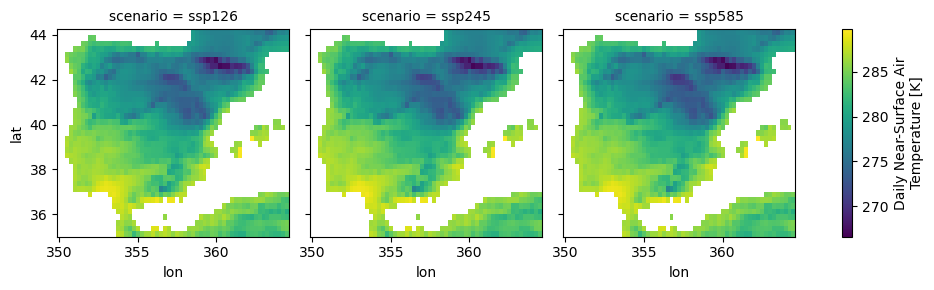

In [7]:
ds["tas"].isel(time=0).plot(col="scenario")

Calculamos la serie temporal para los tres escenarios, utilizando la media espacial de las tres variables.

In [8]:
%%time

ts = ds.mean(["lat", "lon"]).resample({"time": "YE"}).mean().compute(num_workers=4, scheduler="processes").convert_calendar("standard", use_cftime=False, align_on="date").to_array(dim="variable")

CPU times: user 1.45 s, sys: 78.7 ms, total: 1.53 s
Wall time: 50.6 s


Mostramos en un gráfico la evolución de las temperaturas para cada escenario futuro.

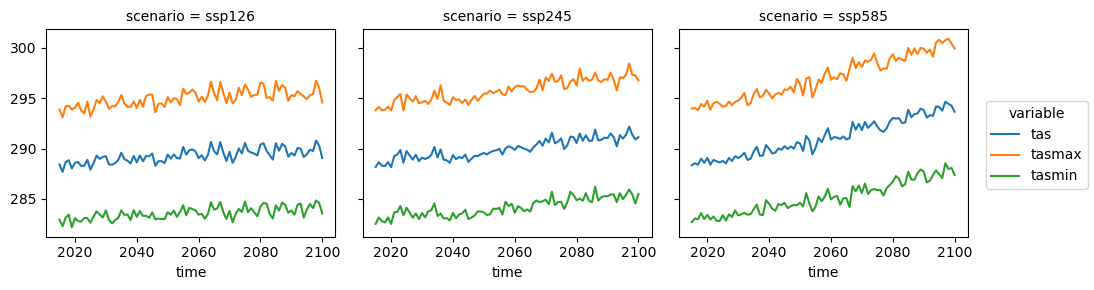

In [9]:
plot = ts.plot.line(x="time", col="scenario", xticks=ts.coords["time"][5::20])

### Comparación multimodelo

Los análisis pueden expandirse para abarcar varios modelos del dataset, siempre y cuando las mallas espacio-temporales sean compatibles. A continuación se muestra un ejemplo que compara las variables de interés para los modelos `MPI-ESM1-2-HR` y `MPI-ESM1-2-LR`, los cuales proveen de información para distintos escenarios futuros.

En primer lugar, localizamos los *endpoints* de interés.

In [10]:
scenarios = ["ssp126", "ssp245", "ssp370", "ssp585"]
model = "MPI-ESM"
subset = gddp[((gddp["dataset"].str.contains(model)) & (gddp["dataset"].str.contains(domain)) & (gddp["experiment"].isin(scenarios)))]
subset

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
404,MPI-ESM1-2-HR_r1i1p1f1_ssp126_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp126,day,https://thredds.climate.ifca.es/thredds/dodsC/...,NaN
405,MPI-ESM1-2-HR_r1i1p1f1_ssp245_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp245,day,https://thredds.climate.ifca.es/thredds/dodsC/...,NaN
406,MPI-ESM1-2-HR_r1i1p1f1_ssp370_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp370,day,https://thredds.climate.ifca.es/thredds/dodsC/...,NaN
407,MPI-ESM1-2-HR_r1i1p1f1_ssp585_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp585,day,https://thredds.climate.ifca.es/thredds/dodsC/...,NaN
409,MPI-ESM1-2-LR_r1i1p1f1_ssp126_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp126,day,https://thredds.climate.ifca.es/thredds/dodsC/...,NaN
410,MPI-ESM1-2-LR_r1i1p1f1_ssp245_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp245,day,https://thredds.climate.ifca.es/thredds/dodsC/...,NaN
411,MPI-ESM1-2-LR_r1i1p1f1_ssp370_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp370,day,https://thredds.climate.ifca.es/thredds/dodsC/...,NaN
412,MPI-ESM1-2-LR_r1i1p1f1_ssp585_Iberia_day_gn,projections,opendap,NEX-GDDP-CMIP6,NCCS,ssp585,day,https://thredds.climate.ifca.es/thredds/dodsC/...,NaN


Una vez localizados los endpoints, generamos el dataset de xarray que contiene todos los datos necesarios para las tres variables (tas, tasmin y tasmax). Ya que estamos analizando variables en superfice, para un conjunto de distintos escenarios futuros y para dos modelos climáticos, las variables climáticas constarán en este caso con 5 dimensiones `(model, scenario, time, lat, lon)`.

In [11]:
ds = xr.concat([
    xr.concat(
        [xr.open_dataset(endpoint)[["tas", "tasmax", "tasmin"]].chunk({"time": 3096}) for endpoint in subset["endpoint"].iloc[:4]],
        dim=xr.Variable("scenario", scenarios),
        coords="minimal",
        compat="override"),
    xr.concat(
        [xr.open_dataset(endpoint)[["tas", "tasmax", "tasmin"]].chunk({"time": 3096}) for endpoint in subset["endpoint"].iloc[4:]],
        dim=xr.Variable("scenario", scenarios),
        coords="minimal",
        compat="override")],
    dim=xr.Variable("model", ["MPI-ESM1-2-HR", "MPI-ESM1-2-LR"]),
    coords="minimal",
    compat="override")

ds

<xarray.Dataset> Size: 7GB
Dimensions:   (model: 2, scenario: 4, time: 31411, lat: 37, lon: 59)
Coordinates:
  * lon       (lon) float64 472B 350.0 350.2 350.5 350.8 ... 364.0 364.2 364.5
  * lat       (lat) float64 296B 35.12 35.38 35.62 35.88 ... 43.62 43.88 44.12
  * time      (time) datetime64[ns] 251kB 2015-01-01T12:00:00 ... 2100-12-31T...
  * scenario  (scenario) <U6 96B 'ssp126' 'ssp245' 'ssp370' 'ssp585'
  * model     (model) <U13 104B 'MPI-ESM1-2-HR' 'MPI-ESM1-2-LR'
Data variables:
    tas       (model, scenario, time, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 3096, 37, 59), meta=np.ndarray>
    tasmax    (model, scenario, time, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 3096, 37, 59), meta=np.ndarray>
    tasmin    (model, scenario, time, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 3096, 37, 59), meta=np.ndarray>
Attributes: (12/25)
    cmip6_source_id:       MPI-ESM1-2-HR
    cmip6_institution_id:  MPI-M
    cmip6_license:         CC-BY 4.0
    activity:              NEX-GDDP-CMIP6
    Conventions:           CF-1.7
    frequency:             day
    ...                    ...
    geospatial_lon_min:    -10.125
    geospatial_lon_max:    4.625
    references:            Thrasher, B., Wang, W., Michaelis, A. et al. NASA ...
    contact:               Ezequiel Cimadevilla (e.cimadevilla@csic.es, https...
    about:                 NASA Earth Exchange Global Daily Downscaled Projec...
    doi:                   https://doi.org/10.7917/OFSG3345

In [12]:
%%time

ts = ds.mean(["lat", "lon"]).resample({"time": "YE"}).mean().compute(num_workers=4, scheduler="processes").convert_calendar("standard", use_cftime=False, align_on="date").to_array(dim="variable")

CPU times: user 3.22 s, sys: 204 ms, total: 3.43 s
Wall time: 2min 8s


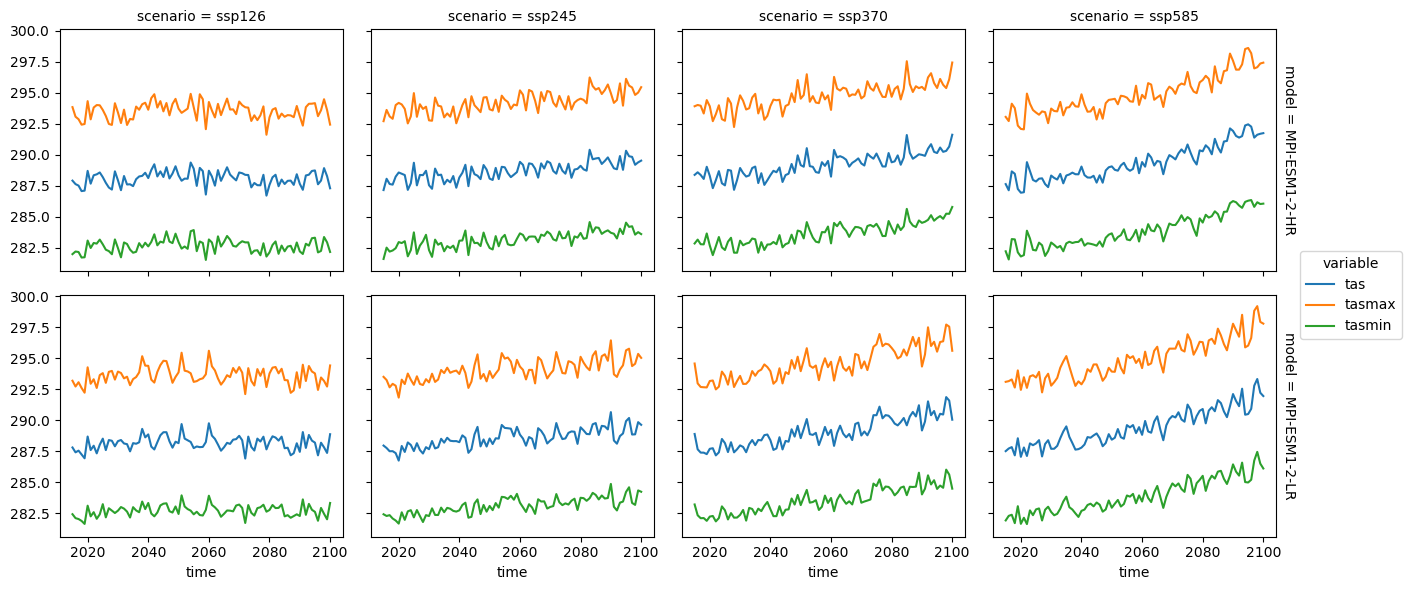

In [13]:
plot = ts.plot.line(x="time", col="scenario", row="model", xticks=ts.coords["time"][5::20])